In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

In [2]:
df_industry = pd.read_csv("data/industry_overview.csv")
df_fin = pd.read_csv("data/company_financials.csv")
df_seg = pd.read_csv("data/market_segments.csv")
df_drivers = pd.read_csv("data/industry_drivers.csv")

print("Industry data shape:", df_industry.shape)
print("Financial data shape:", df_fin.shape)
print("Segments data shape:", df_seg.shape)
print("Drivers data shape:", df_drivers.shape)

Industry data shape: (4, 4)
Financial data shape: (6, 9)
Segments data shape: (6, 4)
Drivers data shape: (5, 2)


In [3]:
df_fin.head()

,Company,StockCode,Revenue_2025_CNY_Billion,NetIncome_2025_CNY_Billion,ROE_2025_Percent,GrossMargin_2025_Percent,NetMargin_2025_Percent,YoY_Revenue_Growth,MainBusiness
0,Jinhe Industrial,002597.SZ,49.11,3.47,4.60,30.37,7.06,-7.39,Sweeteners & Flavors
1,Angel Yeast,600298.SH,167.29,15.44,13.51,NaN,9.23,10.08,Yeast & Fermentation
2,Bailong Chuanyuan,605016.SH,13.79,3.69,NaN,NaN,26.76,19.75,Probiotics & Dietary Fiber
3,Fufeng Group,00546.HK,278.79,24.65,NaN,NaN,8.84,0.40,MSG & Additives
4,Huabao Flavors,300741.SZ,13.38,0.84,NaN,NaN,6.26,NaN,Flavors & Fragrances


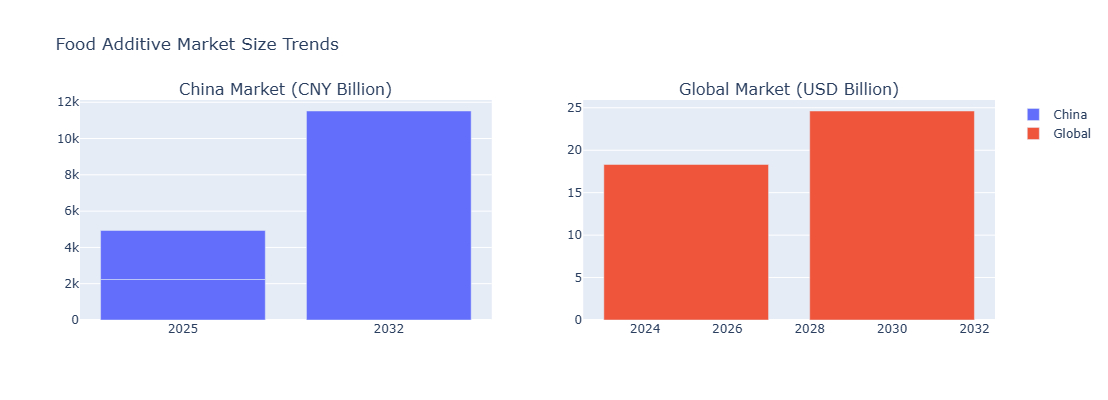

In [4]:
fig = make_subplots(rows=1, cols=2, subplot_titles=("China Market (CNY Billion)", "Global Market (USD Billion)"))

china_data = df_industry[df_industry["Source"].str.contains("ReportsWorld|Beizhe", na=False)]
global_data = df_industry[df_industry["Source"].str.contains("Mordor", na=False)]

fig.add_trace(go.Bar(x=china_data["Year"], y=china_data["MarketSize_CNY_Billion"], name="China"), row=1, col=1)
fig.add_trace(go.Bar(x=global_data["Year"], y=global_data["MarketSize_USD_Billion"], name="Global"), row=1, col=2)
fig.update_layout(height=400, title_text="Food Additive Market Size Trends")
fig.show()

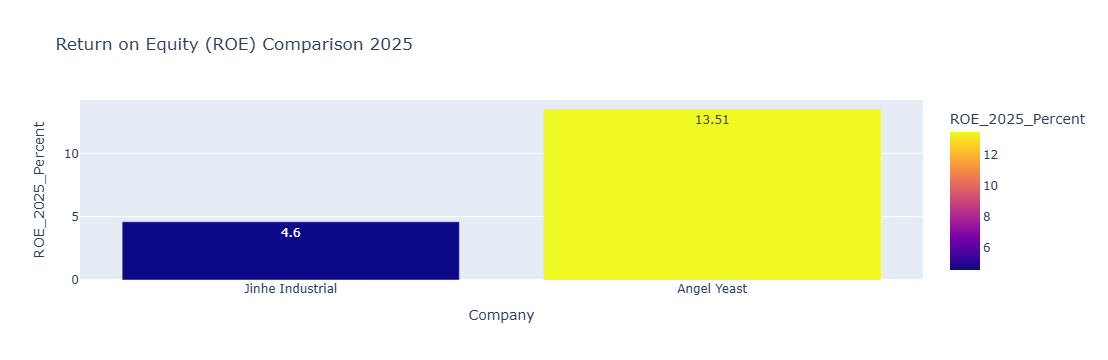

In [5]:
df_roe = df_fin[df_fin["ROE_2025_Percent"].notna() & (df_fin["ROE_2025_Percent"] > 0)]
fig_roe = px.bar(df_roe, x="Company", y="ROE_2025_Percent", 
                 title="Return on Equity (ROE) Comparison 2025",
                 text="ROE_2025_Percent", color="ROE_2025_Percent")
fig_roe.show()

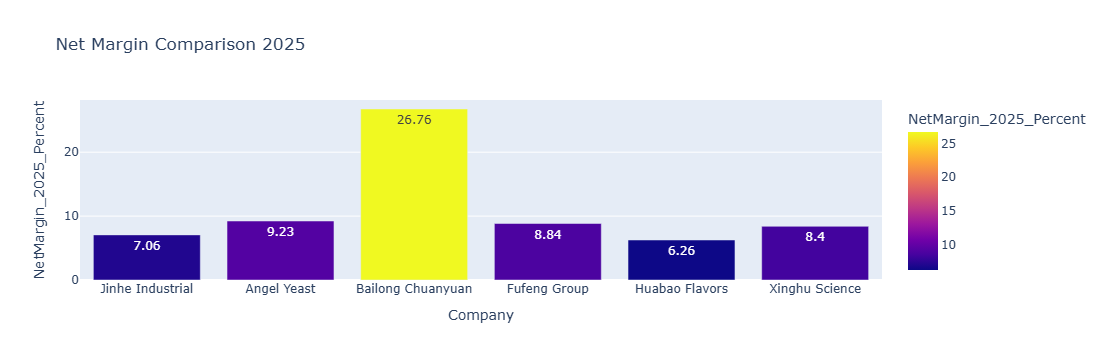

In [6]:
df_nm = df_fin[df_fin["NetMargin_2025_Percent"].notna()]
fig_nm = px.bar(df_nm, x="Company", y="NetMargin_2025_Percent",
                title="Net Margin Comparison 2025",
                text="NetMargin_2025_Percent", color="NetMargin_2025_Percent")
fig_nm.show()

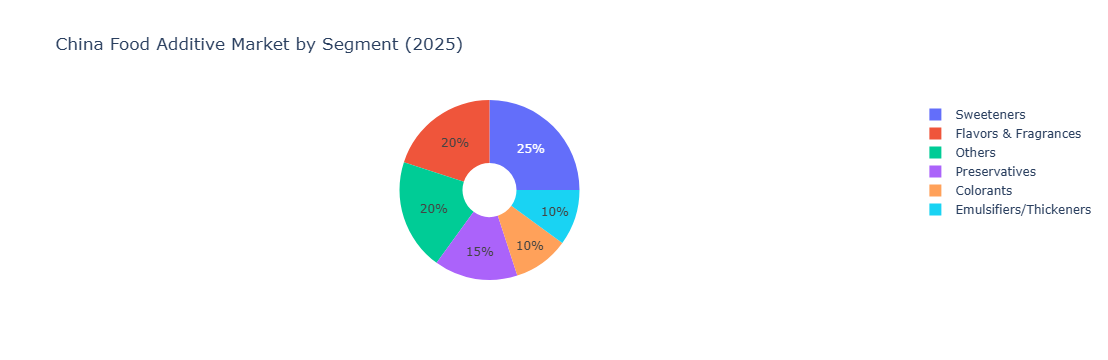

In [7]:
fig_pie = px.pie(df_seg, values="MarketShare_Percent", names="ProductSegment",
                 title="China Food Additive Market by Segment (2025)",
                 hole=0.3)
fig_pie.show()

In [8]:
df_drivers

,Driver,Description
0,Regulation,GB 2760-2024 new standard enforced – stricter ...
1,Health Trend,Natural & functional additives demand >50% of ...
2,Urbanization,66.16% urban population driving packaged food ...
3,Global Expansion,Fufeng and Jinhe expanding overseas capacity
4,Synthetic Biology,Key tech upgrade for fermentation-based ingred...
